In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [26]:
df=pd.read_csv("/content/datadata.csv")

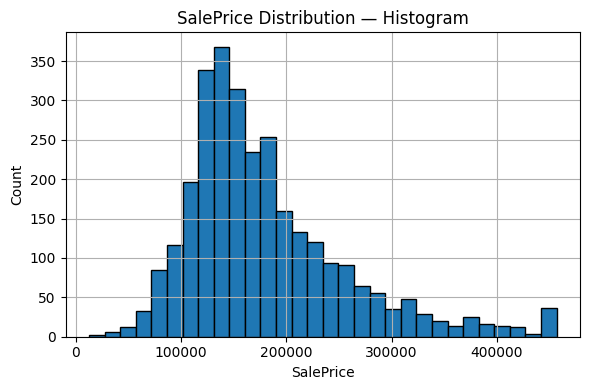

In [5]:
#Histograms (1)
plt.figure(figsize=(6,4))
df["SalePrice"].hist(bins=30,edgecolor="black")
plt.title("SalePrice Distribution — Histogram")
plt.xlabel("SalePrice")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Most prices are between **100,000 and 200,000**

The peak is around **120,000–150,000**

The distribution is **right-skewed**

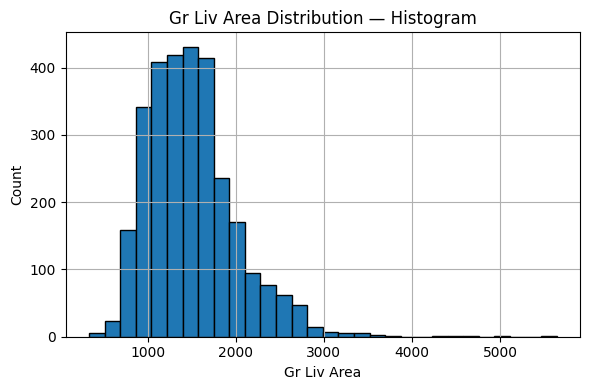

In [6]:
# Histograms (2)
plt.figure(figsize=(6,4))
df["Gr Liv Area"].hist(bins=30,edgecolor="black")
plt.title("Gr Liv Area Distribution — Histogram")
plt.xlabel("Gr Liv Area")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Most homes are between **1,000 and 2,000**

The peak is around **1,200–1,500 **

The distribution is **right-skewed** (few very large homes)

very few homes are above **3000**

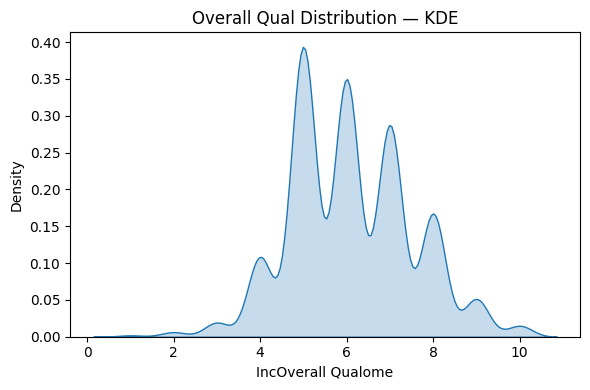

In [7]:
#KDE (3)
plt.figure(figsize=(6, 4))
sns.kdeplot(df["Overall Qual"], fill=True)
plt.title("Overall Qual Distribution — KDE")
plt.xlabel("IncOverall Qualome")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

Peaks around **5–7**, meaning most values are in this range

Slight **right skew** (tail toward higher values)

distribution is **multimodal** because of the multiple peaks

<Axes: title={'center': 'Garage Cars — Boxplot'}, xlabel='Garage Cars', ylabel='SalePrice'>

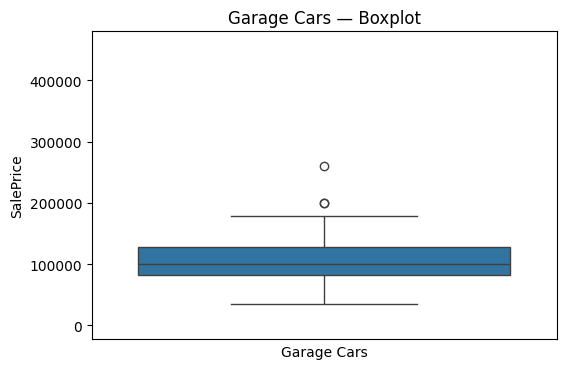

In [8]:
#BoxPlot(1)
plt.figure(figsize=(6, 4))
plt.boxplot(df["Garage Cars"], vert=True, showfliers=True)
plt.title("Garage Cars — Boxplot")
sns.boxplot(x="Garage Cars", y="SalePrice", data=df)

Most prices range around **80,000 to 120,000**

The median price is around **100,000**

There are a few **outliers** above 200,000

Lower price is about **40,000**

<Axes: title={'center': 'Mo Sol — Boxplot'}, xlabel='Mo Sold', ylabel='SalePrice'>

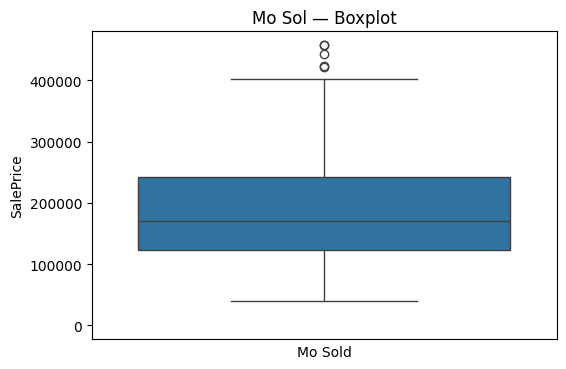

In [9]:
#BoxPlot (2)
plt.figure(figsize=(6, 4))
plt.boxplot(df["Mo Sold"], vert=True, showfliers=True)
plt.title("Mo Sol — Boxplot")
sns.boxplot(x="Mo Sold", y="SalePrice", data=df)

Most prices range around **120,000 to 240,000**

The median price is around **170,000**

There are some **outliers** above 400,000

Lower price about **40,000**



Text(0.5, 1.0, 'Correlation Heatmap')

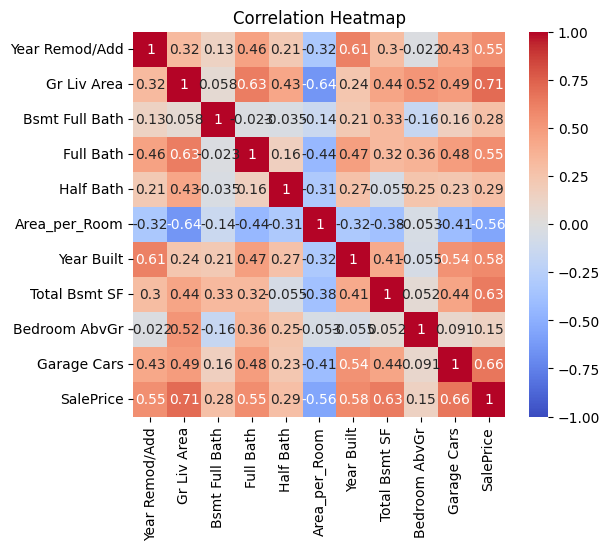

In [29]:
# Correlation heatmap
plt.figure(figsize=(6, 5))
corr=df[['Year Remod/Add','Gr Liv Area','Bsmt Full Bath','Full Bath','Half Bath','Area_per_Room','Year Built','Total Bsmt SF','Bedroom AbvGr','Garage Cars',"SalePrice"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap")

**Strong positive correlations with SalePrice:**
  - Gr Liv Area (0.71)
  - Garage Cars (0.66)
  - Total Bsmt SF (0.63)
  - Year Built (0.58)

  **Weak correlations:**
  - Bedroom AbvGr (0.15)
  - Bsmt Full Bath (0.28)

  **Negative correlation:**
  - Area per Room (-0.56)

Text(0, 0.5, 'SalePrice')

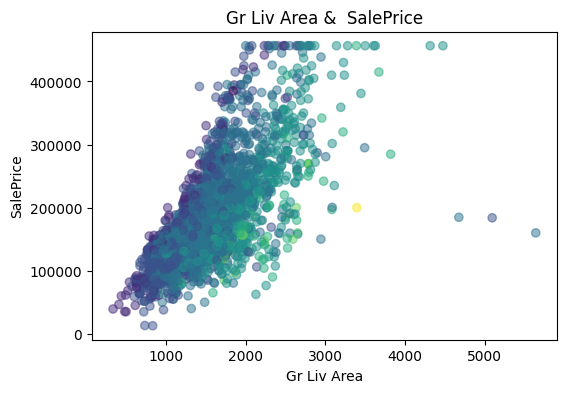

In [36]:
#Scatter Plot
plt.figure(figsize=(6, 4))
plt.scatter(df["Gr Liv Area"], df["SalePrice"],c=df["Bedroom AbvGr"],alpha=0.5)
plt.title("Gr Liv Area &  SalePrice"); plt.xlabel("Gr Liv Area"); plt.ylabel("SalePrice")

There is a **positive correlation**

Most homes between **1,000–2,500** and **$100,000–$300,000**.

A few **outliers** exist with very large areas

Price increases with size

In [48]:
#Groupby summary
OverallQual_groups=df.groupby("Overall Qual")["SalePrice"].mean()
BedroomAbvGr_groups=df.groupby("Bedroom AbvGr")["SalePrice"].mean()
FullBath_groups=df.groupby("Full Bath")["SalePrice"].mean()
GarageCars_groups=df.groupby("Garage Cars")["SalePrice"].mean()
print("OverallQual_groups: ",OverallQual_groups)
print("BedroomAbvGr_groups: ",BedroomAbvGr_groups)
print("FullBath_groups: ",FullBath_groups)
print("GarageCars_groups: ",GarageCars_groups)

OverallQual_groups:  Overall Qual
1      48725.000000
2      52325.307692
3      83185.975000
4     106485.097345
5     134752.516364
6     162130.318306
7     205025.760797
8     270681.212486
9     360229.145327
10    401492.747742
Name: SalePrice, dtype: float64
BedroomAbvGr_groups:  Bedroom AbvGr
0    218494.875000
1    181200.336964
2    161393.932651
3    179628.224308
4    212709.699525
5    204399.299375
6    159701.714286
8    200000.000000
Name: SalePrice, dtype: float64
FullBath_groups:  Full Bath
0    171177.750000
1    134526.015455
2    213865.872493
3    301620.422969
4    241875.000000
Name: SalePrice, dtype: float64
GarageCars_groups:  Garage Cars
0.000000    104949.254777
1.000000    127267.422879
1.766815    150909.000000
2.000000    183562.102932
3.000000    303737.838850
4.000000    228540.335625
5.000000    126500.000000
Name: SalePrice, dtype: float64


Overall Qual is the highest (Strong positive relationship with price)
**Higher quality = higher price**

Bedroom AbvGr is Weak relationship with price

Full Bath is Positive relationship
**More bathrooms = higher price**

Garage Cars is Strong positive trend

**Highest = Overall Qual**

**lowest = Bedroom AbvGr**


# **Math**

In [82]:
mean_target=df["SalePrice"].sum()/len(df["SalePrice"])
mean_numpy=np.mean(df["SalePrice"])
std_target=np.std(df["SalePrice"],ddof=1)

In [59]:
#Standardise
df["Gr Liv Area_z"]=(df["Gr Liv Area"]-np.mean(df["Gr Liv Area"]))/np.std(df["Gr Liv Area"])
df["Total Bsmt SF_z"]=(df["Total Bsmt SF"]-np.mean(df["Total Bsmt SF"]))/np.std(df["Total Bsmt SF"])

from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()
df_sc=df.copy()
df_sc[["Gr Liv Area","Total Bsmt SF"]]=std_scaler.fit_transform(df[["Gr Liv Area","Total Bsmt SF"]])

print(df[["Gr Liv Area_z","Total Bsmt SF_z"]].agg(["mean" , "std"]))#z-score
print(df_sc[["Gr Liv Area","Total Bsmt SF"]].agg(["mean" , "std"]))#StandardScaler

      Gr Liv Area_z  Total Bsmt SF_z
mean   1.455036e-17     7.275182e-18
std    1.000171e+00     1.000171e+00
       Gr Liv Area  Total Bsmt SF
mean  1.091277e-17       0.000000
std   1.000171e+00       1.000171


In [64]:
#cosine similarity
highest=df.max(axis=1)
lowest=df.min(axis=1)
cos_sim=np.dot(highest, lowest) / (np.linalg.norm(highest) * np.linalg.norm(lowest))

-0.769360651701504


In [69]:
#probability
threshold=7
probs=(df["Overall Qual"] >= threshold).astype(int)
print("probs mean: ",probs.mean())

probs mean:  0.3720136518771331


# **Bonus**

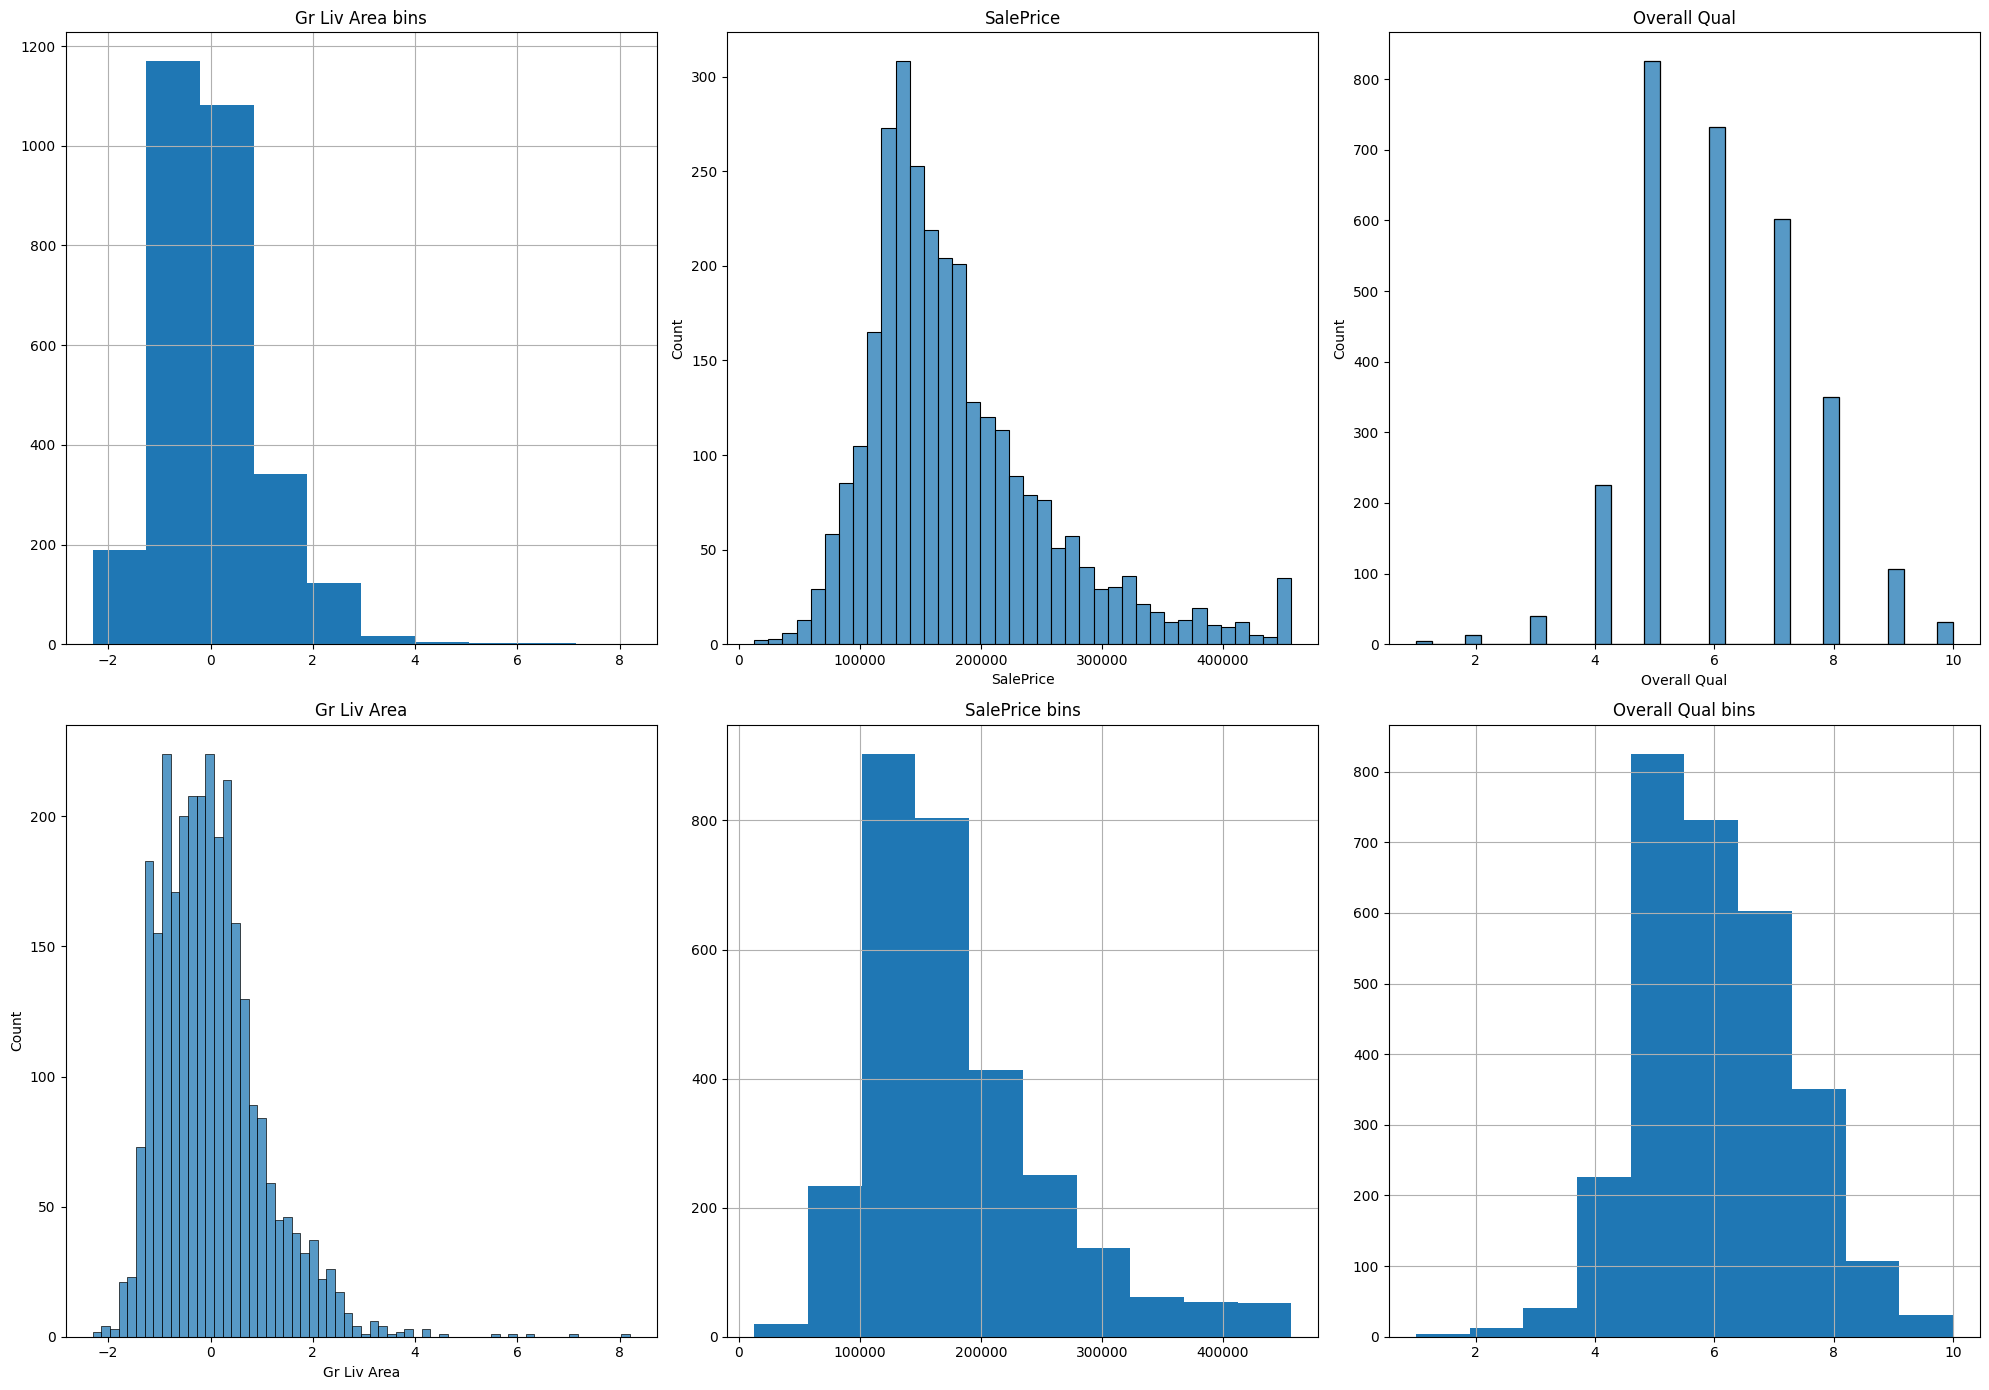

In [80]:
fig, axes = plt.subplots(2, 3, figsize=(20, 14))
sns.histplot(df["SalePrice"], ax=axes[0,1]); axes[0,1].set_title("SalePrice")
sns.histplot(df["Overall Qual"], ax=axes[0,2]); axes[0,2].set_title("Overall Qual")
sns.histplot(df["Gr Liv Area"], ax=axes[1,0]); axes[1,0].set_title("Gr Liv Area")
df["SalePrice"].hist(bins=10, ax=axes[1,1]); axes[1,1].set_title("SalePrice bins")
df["Overall Qual"].hist(bins=10, ax=axes[1,2]); axes[1,2].set_title("Overall Qual bins")
df["Gr Liv Area"].hist(bins=10, ax=axes[0,0]); axes[0,0].set_title("Gr Liv Area bins")
plt.tight_layout(); plt.show()